
TPV Analysis
TPV CSV: /content/drive/MyDrive/Colab Notebooks/BM/TPV-stress/Wearable-Device-Dataset/TPV/Wearable_v2_BVP_TPV_noQC.csv
Detected TPV features: ['TPV0', 'TPV1', 'TPV2', 'TPV3', 'TPV4', 'TPV5', 'TPV6', 'TPV7', 'TPV8', 'TPV9', 'TPV10', 'TPV11', 'TPV12', 'TPV13', 'TPV14', 'TPV15', 'TPV16', 'TPV17', 'TPV18', 'TPV19', 'TPV20', 'TPV21', 'TPV22', 'TPV23', 'TPV24', 'TPV25', 'TPV26', 'TPV27', 'TPV28', 'TPV29', 'TPV30', 'TPV31', 'TPV32']
Total TPV features: 33
state
normal    882
stress    203
Name: count, dtype: int64


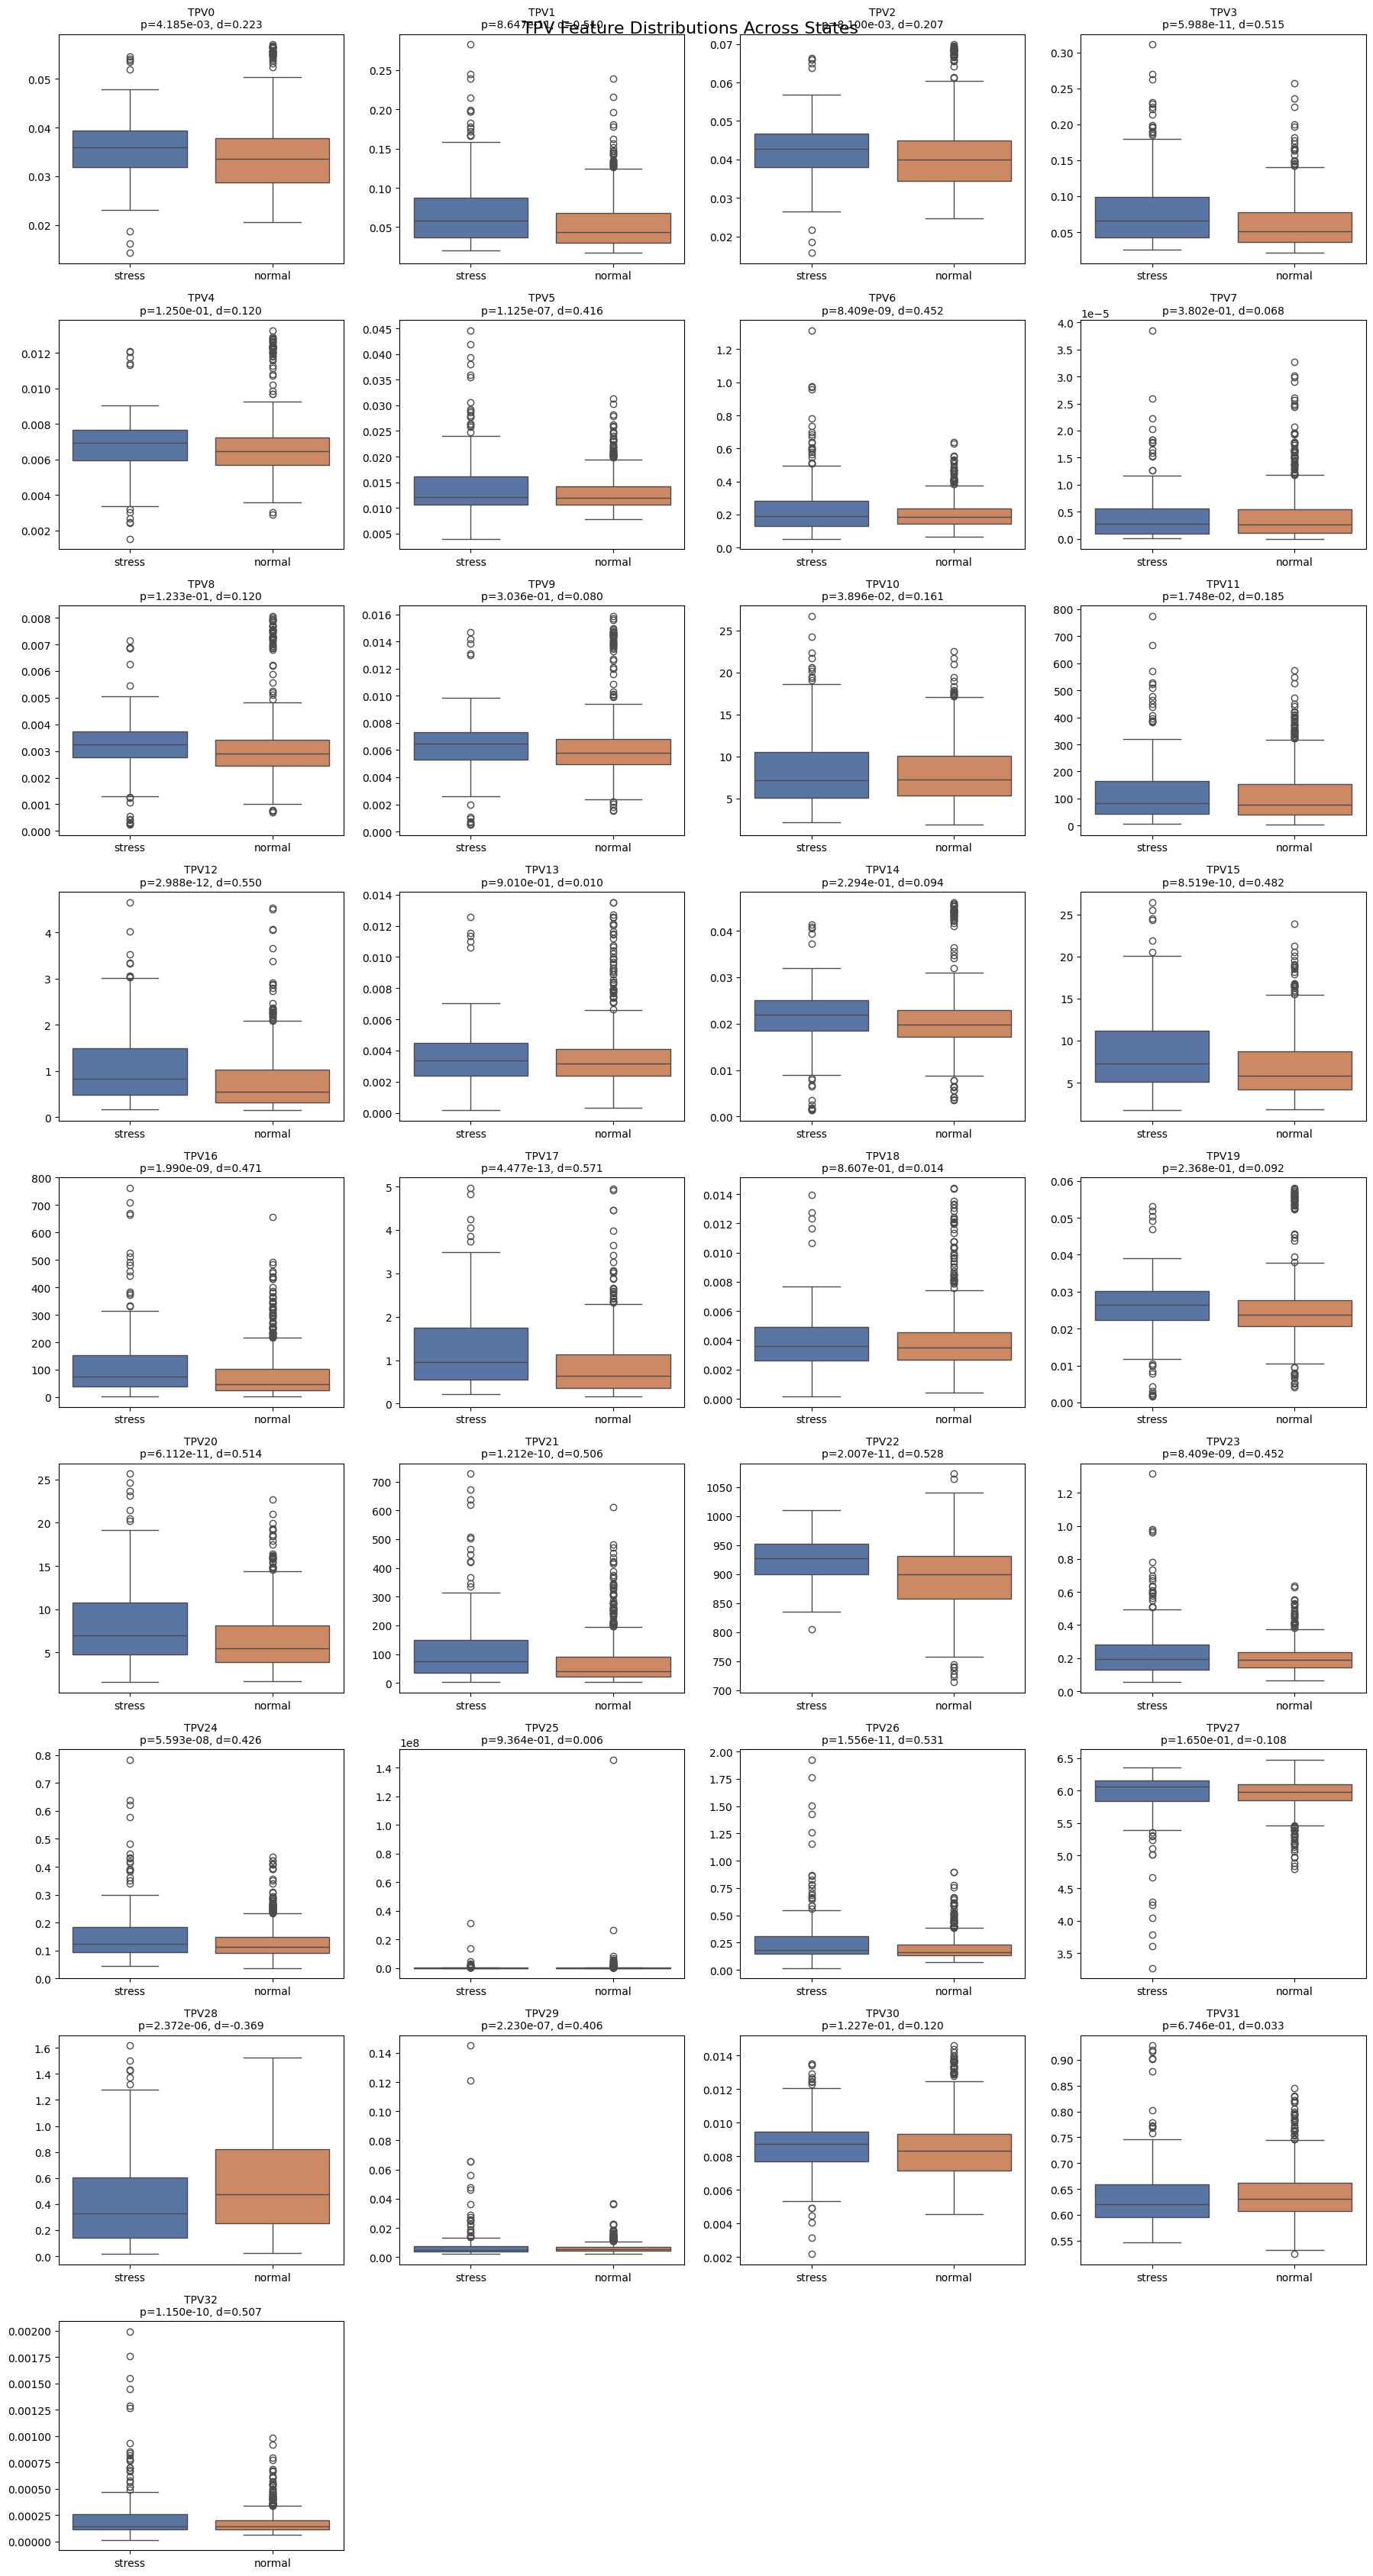


[Saved Figure] /content/drive/MyDrive/Colab Notebooks/BM/TPV-stress/Wearable-Device-Dataset/Feature_Analysis/TPV_all_features_boxplots.png
[Saved Table ] /content/drive/MyDrive/Colab Notebooks/BM/TPV-stress/Wearable-Device-Dataset/Feature_Analysis/TPV_all_features_anova_effect_size.csv

===== Feature Summary sorted by |Cohen's d| =====
feature              Normal (mean±std)              Stress (mean±std)       direction      anova_p  cohens_d  abs_cohens_d  eta_squared  normal_n  stress_n
  TPV17            0.846614 ± 0.649037            1.258155 ± 0.975317 stress > normal 4.476986e-13  0.570648      0.570648     0.047273       882       203
  TPV12            0.752381 ± 0.588822            1.109074 ± 0.864148 stress > normal 2.987867e-12  0.549521      0.549521     0.043988       882       203
  TPV26            0.201861 ± 0.106735            0.282494 ± 0.272301 stress > normal 1.556360e-11  0.530557      0.530557     0.041127       882       203
  TPV22         896.206349 ± 56.88948

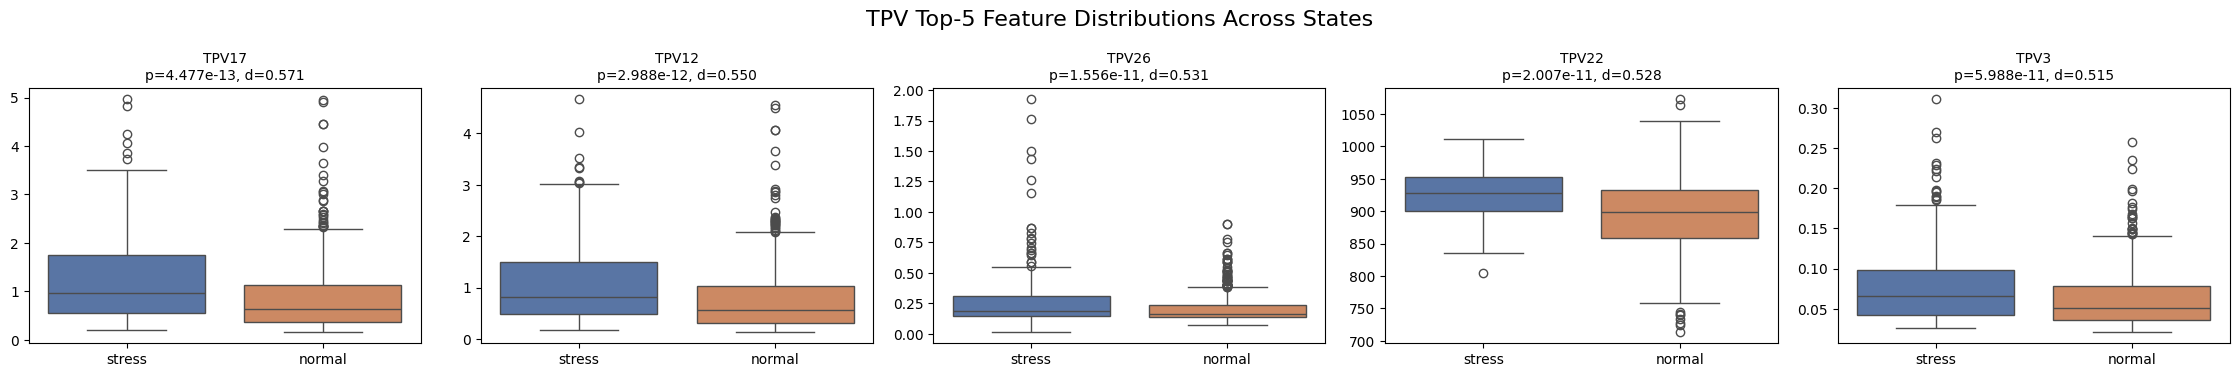


[Saved Figure] /content/drive/MyDrive/Colab Notebooks/BM/TPV-stress/Wearable-Device-Dataset/Feature_Analysis/TPV_top5_features_boxplots.png
[Saved Table ] /content/drive/MyDrive/Colab Notebooks/BM/TPV-stress/Wearable-Device-Dataset/Feature_Analysis/TPV_top5_features_anova_effect_size.csv

===== Feature Summary sorted by |Cohen's d| =====
feature      Normal (mean±std)      Stress (mean±std)       direction      anova_p  cohens_d  abs_cohens_d  eta_squared  normal_n  stress_n
  TPV17    0.846614 ± 0.649037    1.258155 ± 0.975317 stress > normal 4.476986e-13  0.570648      0.570648     0.047273       882       203
  TPV12    0.752381 ± 0.588822    1.109074 ± 0.864148 stress > normal 2.987867e-12  0.549521      0.549521     0.043988       882       203
  TPV26    0.201861 ± 0.106735    0.282494 ± 0.272301 stress > normal 1.556360e-11  0.530557      0.530557     0.041127       882       203
  TPV22 896.206349 ± 56.889486 924.714286 ± 39.228288 stress > normal 2.006948e-11  0.527582      0

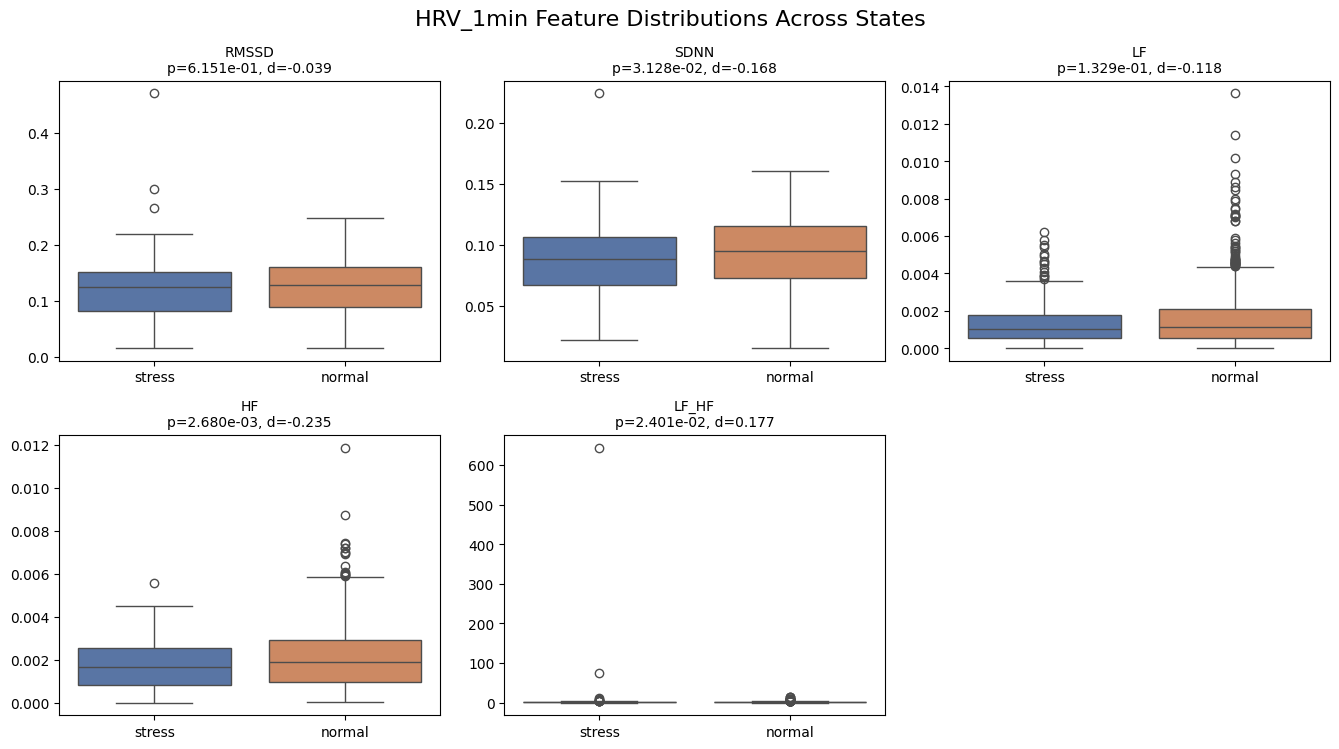


[Saved Figure] /content/drive/MyDrive/Colab Notebooks/BM/TPV-stress/Wearable-Device-Dataset/Feature_Analysis/HRV_1min_5_features_boxplots.png
[Saved Table ] /content/drive/MyDrive/Colab Notebooks/BM/TPV-stress/Wearable-Device-Dataset/Feature_Analysis/HRV_1min_5_features_anova_effect_size.csv

===== Feature Summary sorted by |Cohen's d| =====
feature   Normal (mean±std)    Stress (mean±std)       direction  anova_p  cohens_d  abs_cohens_d  eta_squared  normal_n  stress_n
     HF 0.002091 ± 0.001531  0.001746 ± 0.001168 stress < normal 0.002680 -0.234725      0.234725     0.008300       882       202
  LF_HF 1.189632 ± 1.479875 4.664672 ± 45.629257 stress > normal 0.024013  0.176649      0.176649     0.004703       882       201
   SDNN 0.091394 ± 0.030794  0.086278 ± 0.029050 stress < normal 0.031276 -0.167861      0.167861     0.004275       882       203
     LF 0.001587 ± 0.001541  0.001411 ± 0.001257 stress < normal 0.132872 -0.117552      0.117552     0.002088       882       201


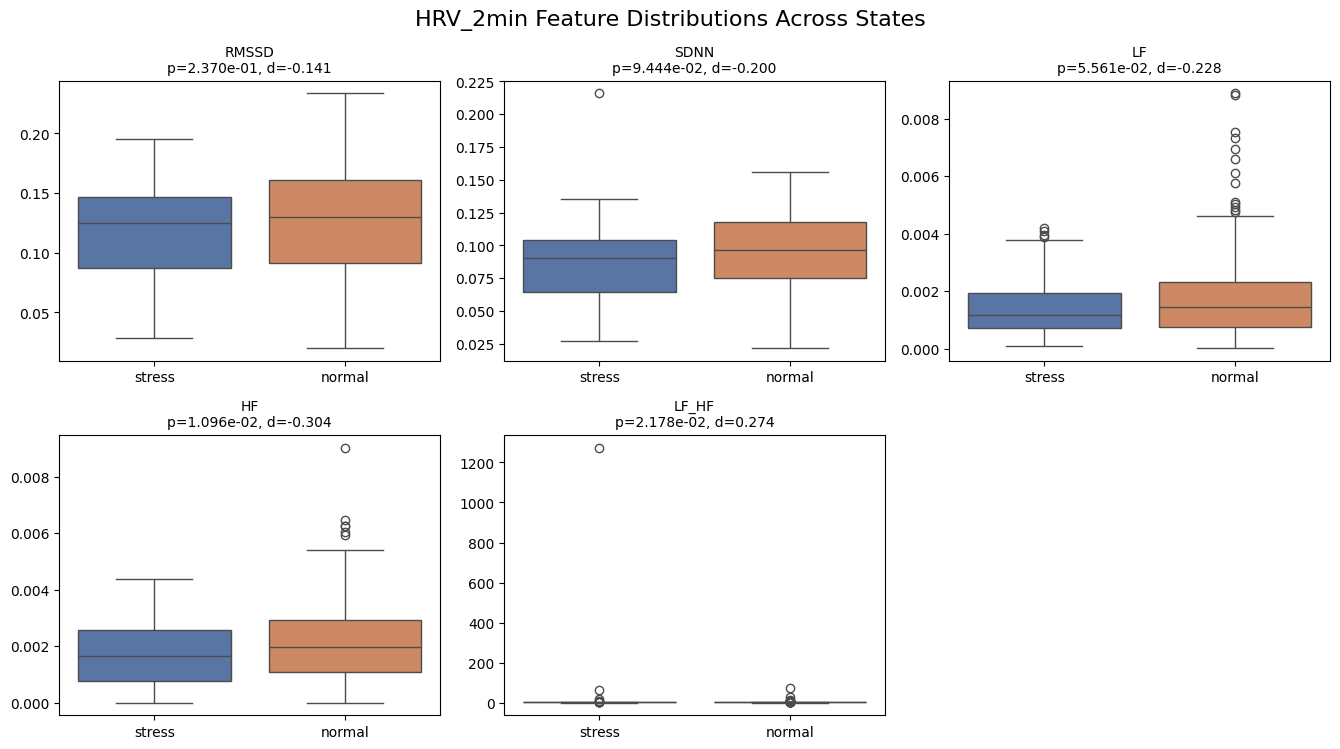


[Saved Figure] /content/drive/MyDrive/Colab Notebooks/BM/TPV-stress/Wearable-Device-Dataset/Feature_Analysis/HRV_2min_5_features_boxplots.png
[Saved Table ] /content/drive/MyDrive/Colab Notebooks/BM/TPV-stress/Wearable-Device-Dataset/Feature_Analysis/HRV_2min_5_features_anova_effect_size.csv

===== Feature Summary sorted by |Cohen's d| =====
feature   Normal (mean±std)      Stress (mean±std)       direction  anova_p  cohens_d  abs_cohens_d  eta_squared  normal_n  stress_n
     HF 0.002063 ± 0.001381    0.001658 ± 0.001075 stress < normal 0.010961 -0.304076      0.304076     0.012950       414        85
  LF_HF 1.416656 ± 3.954687 17.003072 ± 138.065554 stress > normal 0.021784  0.274047      0.274047     0.010544       414        85
     LF 0.001716 ± 0.001339    0.001422 ± 0.000988 stress < normal 0.055606 -0.228470      0.228470     0.007352       414        85
   SDNN 0.093328 ± 0.030196    0.087325 ± 0.029538 stress < normal 0.094443 -0.199533      0.199533     0.005618       414 

In [1]:
# ============================================================
# TPV / HRV Feature Distribution Analysis
# Boxplot + ANOVA + Effect Size
# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway


# ============================================================
# 0. Path 설정
# ============================================================

TPV_CSV_PATH = "/content/drive/MyDrive/Colab Notebooks/BM/TPV-stress/Wearable-Device-Dataset/TPV/Wearable_v2_BVP_TPV_noQC.csv"

HRV_CSV_PATHS = {
    "HRV_1min": "/content/drive/MyDrive/Colab Notebooks/BM/TPV-stress/Wearable-Device-Dataset/HRV/Wearable_v2_HRV_1min_discard.csv",
    "HRV_2min": "/content/drive/MyDrive/Colab Notebooks/BM/TPV-stress/Wearable-Device-Dataset/HRV/Wearable_v2_HRV_2min_discard.csv",
}

SAVE_DIR = "/content/drive/MyDrive/Colab Notebooks/BM/TPV-stress/Wearable-Device-Dataset/Feature_Analysis"
os.makedirs(SAVE_DIR, exist_ok=True)


# ============================================================
# 1. Utility functions
# ============================================================

def prepare_state_column(df):
    df = df.copy()

    if "status_name" in df.columns:
        df["state"] = df["status_name"].replace({
            "normal": "normal",
            "stress": "stress",
            "baseline": "normal"
        })
    elif "status" in df.columns:
        df["state"] = df["status"].map({
            0: "normal",
            1: "stress"
        })
    elif "label_major" in df.columns:
        df["state"] = df["label_major"].map({
            0: "normal",
            1: "stress"
        })
    else:
        raise ValueError("No label column found. Need status_name, status, or label_major.")

    df = df[df["state"].isin(["normal", "stress"])].copy()
    return df


def cohens_d(x1, x2):
    x1 = np.asarray(x1.dropna(), dtype=float)
    x2 = np.asarray(x2.dropna(), dtype=float)

    n1 = len(x1)
    n2 = len(x2)

    if n1 < 2 or n2 < 2:
        return np.nan

    s1 = np.var(x1, ddof=1)
    s2 = np.var(x2, ddof=1)

    pooled_std = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))

    if pooled_std < 1e-12:
        return np.nan

    return (np.mean(x2) - np.mean(x1)) / pooled_std


def eta_squared_anova(groups):
    groups = [np.asarray(g.dropna(), dtype=float) for g in groups]
    groups = [g for g in groups if len(g) > 0]

    if len(groups) < 2:
        return np.nan

    all_data = np.concatenate(groups)
    grand_mean = np.mean(all_data)

    ss_between = sum(len(g) * (np.mean(g) - grand_mean) ** 2 for g in groups)
    ss_total = sum((x - grand_mean) ** 2 for x in all_data)

    if ss_total < 1e-12:
        return np.nan

    return ss_between / ss_total


def analyze_features(df, features, title, save_prefix, n_cols=4):
    results = []

    n_features = len(features)
    n_rows = math.ceil(n_features / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4.5 * n_cols, 3.8 * n_rows)
    )

    if n_features == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for i, feature in enumerate(features):
        data = df[["state", feature]].copy()
        data[feature] = pd.to_numeric(data[feature], errors="coerce")
        data = data.dropna()

        normal = data[data["state"] == "normal"][feature]
        stress = data[data["state"] == "stress"][feature]

        if len(normal) < 2 or len(stress) < 2:
            anova_p = np.nan
            d = np.nan
            eta2 = np.nan
        else:
            anova_p = f_oneway(normal, stress).pvalue
            d = cohens_d(normal, stress)
            eta2 = eta_squared_anova([normal, stress])

        summary = data.groupby("state")[feature].agg(["mean", "std", "count"])

        normal_mean = summary.loc["normal", "mean"] if "normal" in summary.index else np.nan
        normal_std = summary.loc["normal", "std"] if "normal" in summary.index else np.nan
        normal_count = summary.loc["normal", "count"] if "normal" in summary.index else 0

        stress_mean = summary.loc["stress", "mean"] if "stress" in summary.index else np.nan
        stress_std = summary.loc["stress", "std"] if "stress" in summary.index else np.nan
        stress_count = summary.loc["stress", "count"] if "stress" in summary.index else 0

        direction = (
            "stress > normal"
            if stress_mean > normal_mean
            else "stress < normal"
        )

        results.append({
            "feature": feature,
            "normal_mean": normal_mean,
            "normal_std": normal_std,
            "normal_n": int(normal_count),
            "stress_mean": stress_mean,
            "stress_std": stress_std,
            "stress_n": int(stress_count),
            "direction": direction,
            "anova_p": anova_p,
            "cohens_d": d,
            "abs_cohens_d": abs(d) if np.isfinite(d) else np.nan,
            "eta_squared": eta2
        })

        sns.boxplot(
            x="state",
            y=feature,
            data=data,
            ax=axes[i],
            palette=["#4C72B0", "#DD8452"]
        )

        axes[i].set_title(
            f"{feature}\np={anova_p:.3e}, d={d:.3f}" if np.isfinite(anova_p) else feature,
            fontsize=10
        )
        axes[i].set_xlabel("")
        axes[i].set_ylabel("")

    for j in range(n_features, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()

    fig_path = os.path.join(SAVE_DIR, f"{save_prefix}_boxplots.png")
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    results_df = pd.DataFrame(results)

    results_df["Normal (mean±std)"] = results_df.apply(
        lambda r: f"{r['normal_mean']:.6f} ± {r['normal_std']:.6f}",
        axis=1
    )

    results_df["Stress (mean±std)"] = results_df.apply(
        lambda r: f"{r['stress_mean']:.6f} ± {r['stress_std']:.6f}",
        axis=1
    )

    results_df = results_df.sort_values(
        by=["abs_cohens_d", "anova_p"],
        ascending=[False, True]
    ).reset_index(drop=True)

    csv_path = os.path.join(SAVE_DIR, f"{save_prefix}_anova_effect_size.csv")
    results_df.to_csv(csv_path, index=False, encoding="utf-8-sig")

    print(f"\n[Saved Figure] {fig_path}")
    print(f"[Saved Table ] {csv_path}")

    print("\n===== Feature Summary sorted by |Cohen's d| =====")
    display_cols = [
        "feature",
        "Normal (mean±std)",
        "Stress (mean±std)",
        "direction",
        "anova_p",
        "cohens_d",
        "abs_cohens_d",
        "eta_squared",
        "normal_n",
        "stress_n"
    ]
    print(results_df[display_cols].to_string(index=False))

    return results_df


# ============================================================
# 2. TPV 분석
# ============================================================

df_tpv = pd.read_csv(TPV_CSV_PATH)
df_tpv = prepare_state_column(df_tpv)

tpv_features = [c for c in df_tpv.columns if c.startswith("TPV")]

print("\n==============================")
print("TPV Analysis")
print("==============================")
print("TPV CSV:", TPV_CSV_PATH)
print("Detected TPV features:", tpv_features)
print("Total TPV features:", len(tpv_features))
print(df_tpv["state"].value_counts())

tpv_results = analyze_features(
    df=df_tpv,
    features=tpv_features,
    title="TPV Feature Distributions Across States",
    save_prefix="TPV_all_features",
    n_cols=4
)

tpv_top5 = tpv_results.head(5)["feature"].tolist()

print("\n===== TPV Top-5 Features by |Cohen's d| =====")
print(tpv_top5)

tpv_top5_path = os.path.join(SAVE_DIR, "TPV_top5_features_by_effect_size.csv")
tpv_results.head(5).to_csv(tpv_top5_path, index=False, encoding="utf-8-sig")
print("[Saved TPV Top-5]", tpv_top5_path)


# ============================================================
# 3. TPV Top-5만 따로 Boxplot
# ============================================================

tpv_top5_results = analyze_features(
    df=df_tpv,
    features=tpv_top5,
    title="TPV Top-5 Feature Distributions Across States",
    save_prefix="TPV_top5_features",
    n_cols=5
)


# ============================================================
# 4. HRV 분석
# ============================================================

hrv_all_results = []

for hrv_tag, hrv_path in HRV_CSV_PATHS.items():
    df_hrv = pd.read_csv(hrv_path)
    df_hrv = prepare_state_column(df_hrv)

    hrv_features = ["RMSSD", "SDNN", "LF", "HF", "LF_HF"]
    hrv_features = [f for f in hrv_features if f in df_hrv.columns]

    print("\n==============================")
    print(f"{hrv_tag} Analysis")
    print("==============================")
    print("HRV CSV:", hrv_path)
    print("HRV features:", hrv_features)
    print("Total HRV features:", len(hrv_features))
    print(df_hrv["state"].value_counts())

    hrv_results = analyze_features(
        df=df_hrv,
        features=hrv_features,
        title=f"{hrv_tag} Feature Distributions Across States",
        save_prefix=f"{hrv_tag}_5_features",
        n_cols=3
    )

    hrv_results["window"] = hrv_tag
    hrv_results["feature_type"] = "HRV"
    hrv_all_results.append(hrv_results)

hrv_all_results = pd.concat(hrv_all_results, axis=0, ignore_index=True)

hrv_all_path = os.path.join(SAVE_DIR, "HRV_1min_2min_feature_summary.csv")
hrv_all_results.to_csv(hrv_all_path, index=False, encoding="utf-8-sig")

print("\n===== HRV 1min + 2min Summary =====")
print(
    hrv_all_results[
        [
            "window",
            "feature",
            "Normal (mean±std)",
            "Stress (mean±std)",
            "direction",
            "anova_p",
            "cohens_d",
            "abs_cohens_d",
            "eta_squared",
            "normal_n",
            "stress_n"
        ]
    ].sort_values(["window", "abs_cohens_d"], ascending=[True, False]).to_string(index=False)
)

print("\n[Saved HRV 1min+2min Summary]", hrv_all_path)


# ============================================================
# 5. TPV Top-5 vs HRV 5개 요약 비교표 저장
# ============================================================

tpv_compare = tpv_results[tpv_results["feature"].isin(tpv_top5)].copy()
tpv_compare["feature_type"] = "TPV"
tpv_compare["window"] = "TPV_1min"

hrv_compare = hrv_all_results.copy()

compare_df = pd.concat([tpv_compare, hrv_compare], axis=0, ignore_index=True)

compare_df = compare_df[
    [
        "feature_type",
        "window",
        "feature",
        "Normal (mean±std)",
        "Stress (mean±std)",
        "direction",
        "anova_p",
        "cohens_d",
        "abs_cohens_d",
        "eta_squared",
        "normal_n",
        "stress_n"
    ]
].sort_values(["feature_type", "window", "abs_cohens_d"], ascending=[True, True, False])

compare_path = os.path.join(SAVE_DIR, "TPV_top5_vs_HRV_1min_2min_summary.csv")
compare_df.to_csv(compare_path, index=False, encoding="utf-8-sig")

print("\n===== TPV Top-5 vs HRV 1min/2min Summary =====")
print(compare_df.to_string(index=False))
print("\n[Saved Compare Table]", compare_path)